In [1]:
from google.colab import files
uploaded = files.upload()

Saving Photo on 7-3-24 at 6.55 PM.jpg to Photo on 7-3-24 at 6.55 PM.jpg


In [3]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.5/921.5 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from google.colab import files
uploaded = files.upload()

In [4]:
import os
print(os.listdir("/content/"))

['.config', 'Photo on 7-3-24 at 6.55\u202fPM.jpg', 'sample_data']


In [8]:

# Get the filename (assuming one file uploaded)
filename = list(uploaded.keys())[0]
image_path = f"/content/{filename}"
print(image_path)

/content/Photo on 7-3-24 at 6.55 PM.jpg



image 1/1 /content/Photo on 7-3-24 at 6.55 PM.jpg: 448x640 1 person, 1 dog, 2274.1ms
Speed: 3.5ms preprocess, 2274.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


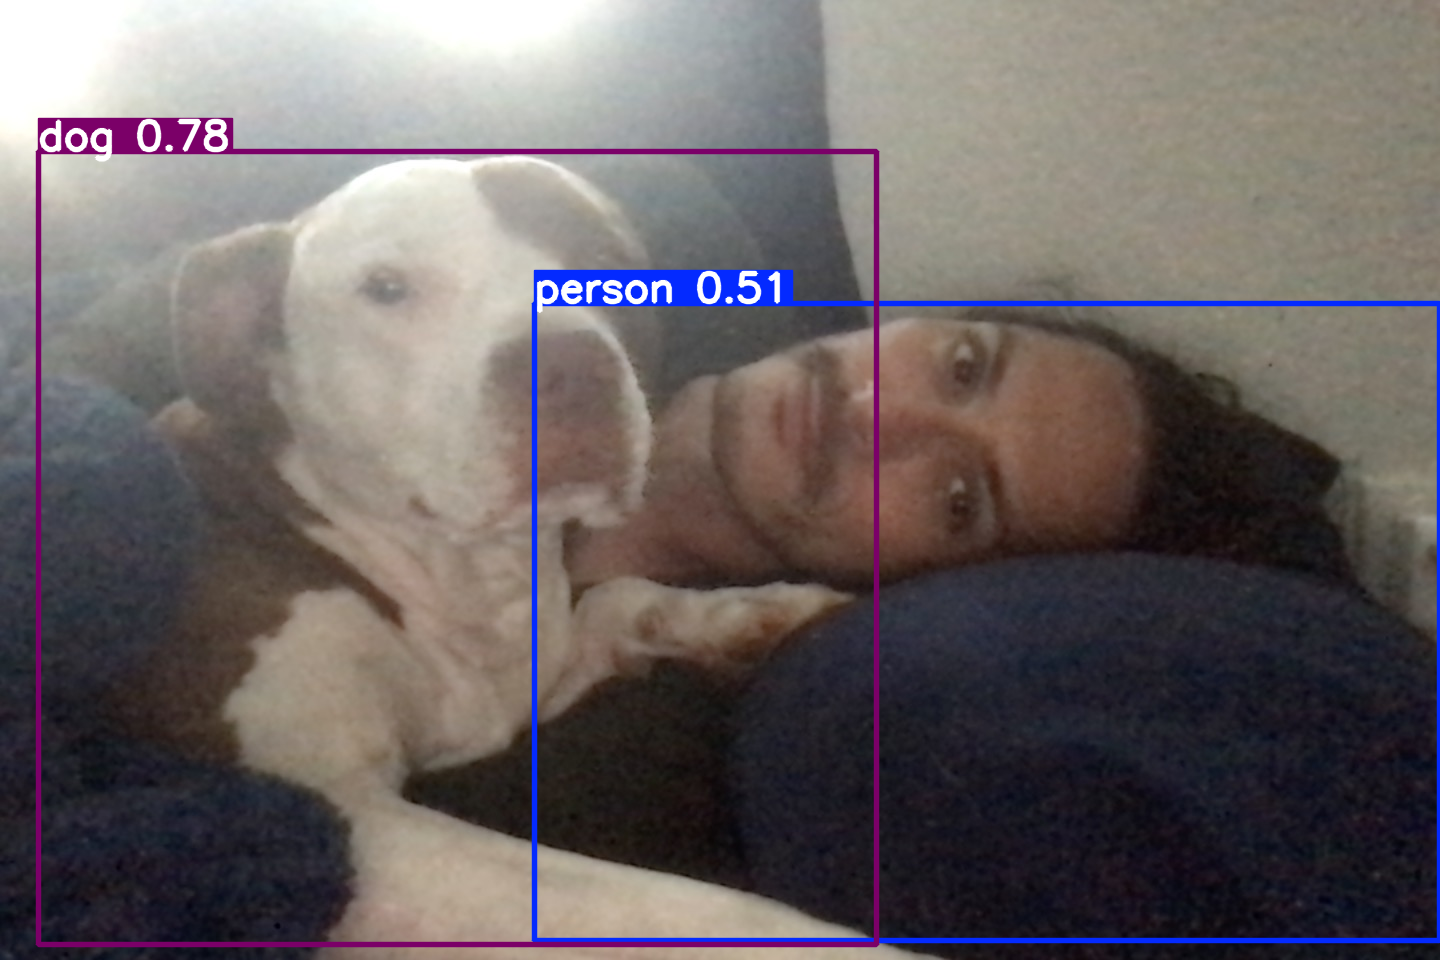


Detected Objects:
Object: dog, Confidence: 0.78, Box: (x:457.8, y:547.8, w:838.4, h:792.9)
Object: person, Confidence: 0.51, Box: (x:986.6, y:621.7, w:905.1, h:637.4)
Annotated image saved as 'annotated_image.jpg' in Colab runtime.


In [13]:
from ultralytics import YOLO
from google.colab import files
from ultralytics import YOLO
from PIL import Image


model = YOLO("yolov8m.pt")

results = model.predict(image_path, conf=0.5, augment=True)

results[0].show()

print("\nDetected Objects:")
for result in results:
    for box in result.boxes:
        label = result.names[int(box.cls)]  # Class name
        confidence = box.conf.item()  # Confidence score as float
        x, y, w, h = [v.item() for v in box.xywh[0]]  # Bounding box coordinates as floats
        print(f"Object: {label}, Confidence: {confidence:.2f}, Box: (x:{x:.1f}, y:{y:.1f}, w:{w:.1f}, h:{h:.1f})")

results[0].save(filename="annotated_image.jpg")
print("Annotated image saved as 'annotated_image.jpg' in Colab runtime.")


